<a href="https://colab.research.google.com/github/Hugh-Carlson/CSC576DataMining/blob/main/CSC576HW6ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
data = pd.read_csv('gila_river.csv')

In [17]:
data.head()

,y(t-1),y(t-2),y(t-3),y(t)
0,0.0,0.0,0.0,32.0
1,32.0,0.0,0.0,27.0
2,27.0,32.0,0.0,27.0
3,27.0,27.0,32.0,25.0
4,25.0,27.0,27.0,27.0


In [18]:
data.shape

(1034, 4)

In [19]:
X = data.drop(columns=['y(t)'])
y = data['y(t)']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42)

In [21]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
mlp = MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=3000)

In [23]:
mlp.fit(X_train, y_train)

MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=3000)

In [24]:
y_train_pred = mlp.predict(X_train)
y_test_pred = mlp.predict(X_test)


In [25]:
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

In [26]:
print(f"Training MSE: {mse_train}")
print(f"Testing MSE: {mse_test}")


Training MSE: 61259.3684384575
Testing MSE: 23791.44717951927


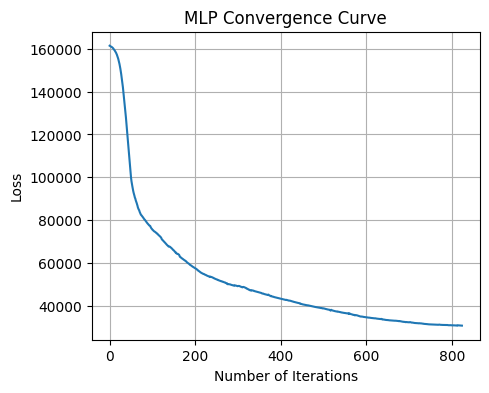

In [27]:
plt.figure(figsize=(5, 4))
plt.plot(mlp.loss_curve_)
plt.title("MLP Convergence Curve")
plt.xlabel("Number of Iterations")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

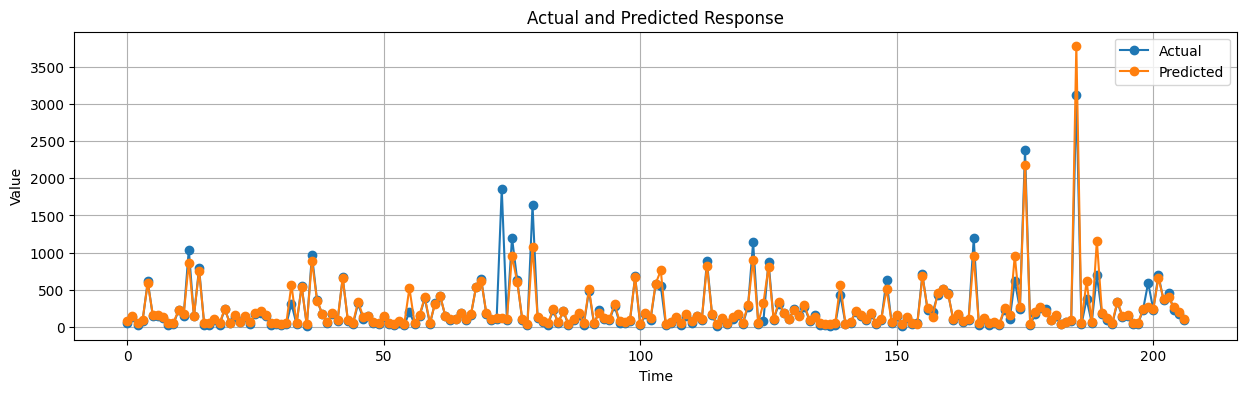

In [28]:
t = range(len(y_test))

plt.figure(figsize=(15, 4))
plt.plot(t, y_test, label='Actual', linestyle = '-', marker = 'o')
plt.plot(t, y_test_pred, label='Predicted', linestyle = '-', marker = 'o')
plt.title("Actual and Predicted Response")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.show()


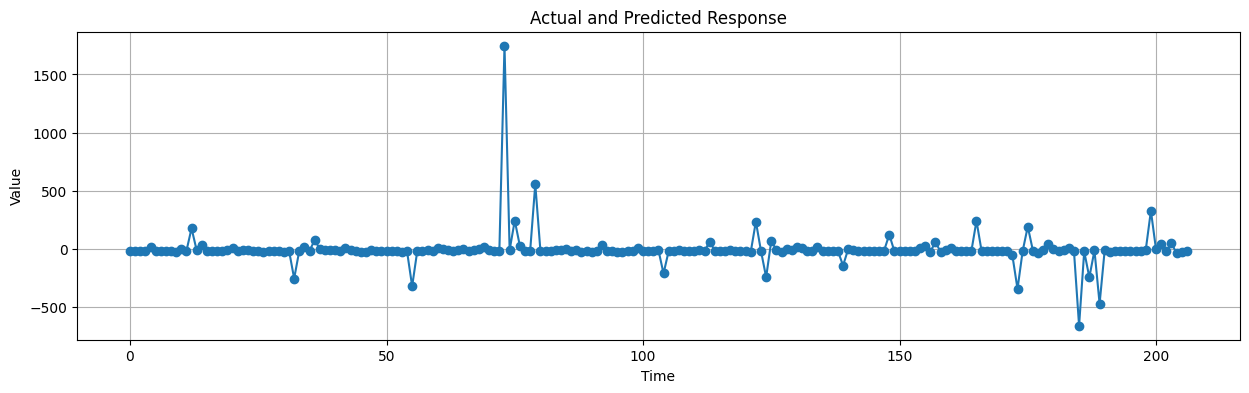

In [29]:
t = range(len(y_test))

plt.figure(figsize=(15, 4))
plt.plot(t, y_test - y_test_pred, label='Actual', linestyle = '-', marker = 'o')
plt.title("Actual and Predicted Response")
plt.xlabel("Time")
plt.ylabel("Value")
# plt.legend()
plt.grid(True)

plt.show()

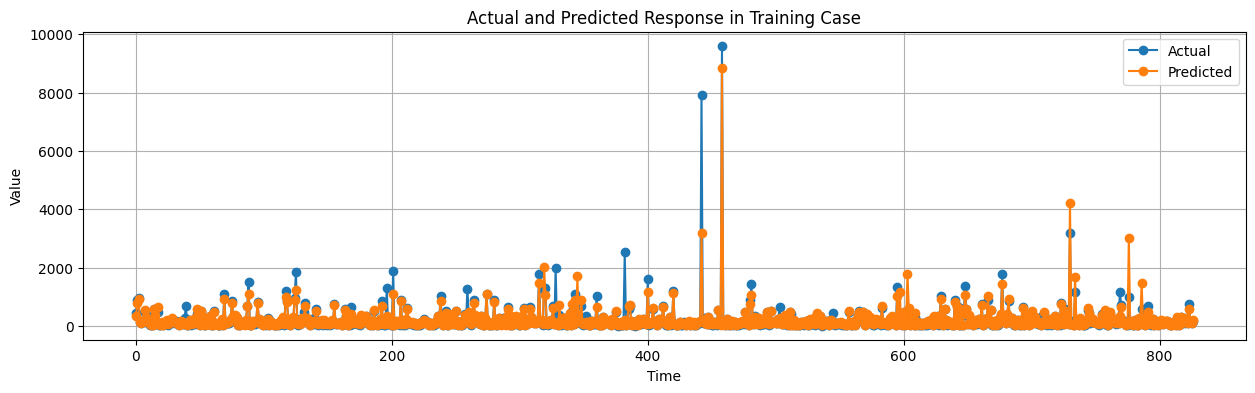

In [30]:
# Move to before training code cell
t = range(len(y_train))

plt.figure(figsize=(15, 4))
plt.plot(t, y_train, label='Actual', linestyle = '-', marker = 'o')
plt.plot(t, y_train_pred, label='Predicted', linestyle = '-', marker = 'o')
plt.title("Actual and Predicted Response in Training Case")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.show()